In [37]:
import os
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [38]:
# Adjust this path to your dataset location
csv_path = r'C:/Users/Vido/Desktop/EPL448/accepted_2007_to_2018q4.csv/accepted_2007_to_2018q4.csv'
if not os.path.exists(csv_path):
    raise FileNotFoundError(f'CSV file not found at {csv_path}')

# Use a smaller sample for rapid iteration, or set sample_n=None for full data
sample_n = None
df = pd.read_csv(csv_path, low_memory=False, nrows=sample_n)
print('Loaded rows:', len(df))

Loaded rows: 2260701


In [39]:
# Keep binary target only
df = df[df['loan_status'].isin(['Fully Paid', 'Charged Off'])].copy()
df['target'] = (df['loan_status'] == 'Charged Off').astype(int)

# Reduce to core features for emp_length clustering plus strong predictors
features = ['loan_amnt','term','int_rate','dti','annual_inc','open_acc','total_acc','revol_bal','revol_util','grade','sub_grade','home_ownership','verification_status','emp_length']
available = [c for c in features if c in df.columns]
print('Using columns', available)
df = df[available + ['target']]

Using columns ['loan_amnt', 'term', 'int_rate', 'dti', 'annual_inc', 'open_acc', 'total_acc', 'revol_bal', 'revol_util', 'grade', 'sub_grade', 'home_ownership', 'verification_status', 'emp_length']


In [40]:
# Inspect raw emp_length distribution before preprocessing
print('emp_length unique count:', df['emp_length'].nunique(dropna=False))
print('emp_length value counts')
print(df['emp_length'].value_counts(dropna=False))

# Normalize and keep emp_length categories
def normalize_emp_length(e):
    #Find Unknowns-Empty values
    if pd.isna(e):
        return 'Unknown'
    s = str(e).strip()
    if s in ['n/a', 'Unknown', '']:
        return 'Unknown'

    # Flatten common suffixes and whitespace
    s = s.replace(' years', '').replace(' year', '').strip()

    # Convert edge cases
    if s.startswith('<'):
        # "< 1" or "<1" -> 0
        return '0'
    if s.endswith('+'):
        # "10+" -> 10
        s = s[:-1]

    # remove any leftover '+' or non-digit text
    s = s.strip().replace('+', '').strip()

    try:
        v = int(s)
        return str(v)
    except Exception:
        return 'Unknown'

df['emp_length_norm'] = df['emp_length'].apply(normalize_emp_length)
df['emp_length_is_unknown'] = (df['emp_length_norm'] == 'Unknown').astype(int)

# Derive categories dynamically and sort them
vals = [int(x) for x in df['emp_length_norm'] if x != 'Unknown' and x.isdigit()]
vals = sorted(set(vals))
unique_emp_length = [str(x) for x in vals] + ['Unknown']
print('cached emp_length categories:', unique_emp_length)

# Create numeric version of emp_length for clustering, with 'Unknown' as the last category
code_map = {v: i for i, v in enumerate(unique_emp_length)}
df['emp_length_code'] = df['emp_length_norm'].map(code_map).fillna(len(unique_emp_length) - 1).astype(int)


emp_length unique count: 12
emp_length value counts
emp_length
10+ years    442199
2 years      121743
< 1 year     108061
3 years      107597
1 year        88494
5 years       84154
4 years       80556
NaN           78511
6 years       62733
8 years       60701
7 years       59624
9 years       50937
Name: count, dtype: int64
cached emp_length categories: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', 'Unknown']


Cluster assignment counts:
emp_cluster
 2    722843
 0    336654
 1    285439
-1       374
Name: count, dtype: int64


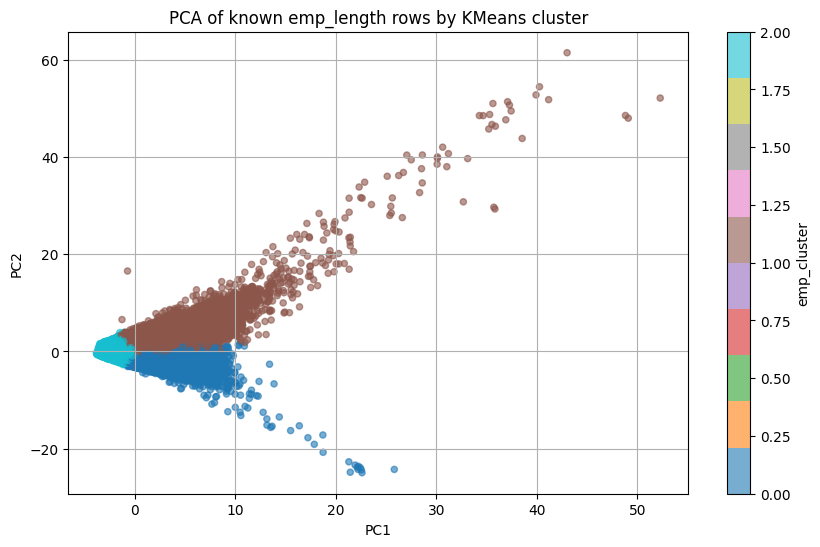

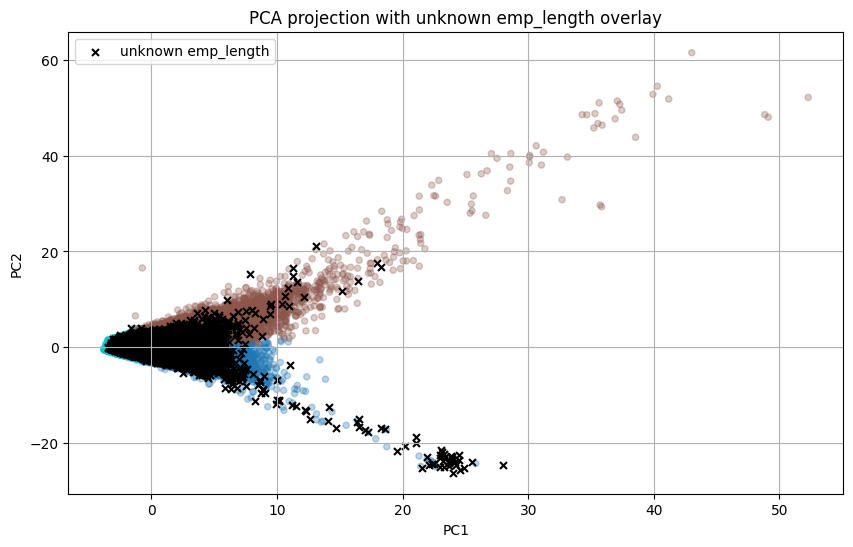

Cluster emp_length summary (known):
             median      mean   count
emp_cluster                          
0               7.0  6.268992  317191
1               9.0  7.038034  274726
2               5.0  5.387058  674865


In [41]:
# Cluster on rows with known emp_length only (avoid unknown in kmeans)
cluster_on = ['loan_amnt','dti','annual_inc','open_acc','total_acc','revol_bal','emp_length_code']
known_df = df[df['emp_length_is_unknown'] == 0].copy()
known_df = known_df.dropna(subset=cluster_on)
# Create numeric emp_length for summary (Unknown = -1, but known_df has no Unknown)
known_df['emp_length_num'] = known_df['emp_length_norm'].astype(int)
# Precompute numeric revol_util once for known rows
known_df['revol_util_num'] = pd.to_numeric(
    known_df['revol_util'].astype(str).str.replace('%', '', regex=False),
    errors='coerce'
).fillna(0)
X = known_df[cluster_on].copy()
# Use precomputed revol_util
X['revol_util'] = known_df['revol_util_num']
#Normalize features for clustering
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
#Using 3 clusters after trying a range of values and inspecting cluster centers and distributions
n_clusters = 3
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
known_df['emp_cluster'] = kmeans.fit_predict(X_scaled)

# Apply nearest cluster to unknown rows by distance from cluster centers
unknown_df = df[df['emp_length_is_unknown'] == 1].copy()
unknown_df = unknown_df.dropna(subset=cluster_on)
# Precompute numeric revol_util once for unknown rows
unknown_df['revol_util_num'] = pd.to_numeric(
    unknown_df['revol_util'].astype(str).str.replace('%', '', regex=False),
    errors='coerce'
).fillna(0)
X_unknown = unknown_df[cluster_on].copy()
# Use precomputed revol_util
X_unknown['revol_util'] = unknown_df['revol_util_num']
X_unknown_scaled = scaler.transform(X_unknown)

distances = np.linalg.norm(X_unknown_scaled[:,None,:] - kmeans.cluster_centers_[None,:,:], axis=2)
unknown_df['emp_cluster'] = np.argmin(distances, axis=1)

# Combine clusters back into main df
# Initialize emp_cluster column with NaN
df['emp_cluster'] = np.nan
# Update with cluster labels from known and unknown subsets
df.update(known_df[['emp_cluster']])
df.update(unknown_df[['emp_cluster']])
# Fill any remaining NaN with -1 and convert to int
df['emp_cluster'] = df['emp_cluster'].fillna(-1).astype(int)

# Print summary of cluster assignments
print('Cluster assignment counts:')
print(df['emp_cluster'].value_counts())

# Plot clusters using PCA on the same feature space
# Features for PCA plotting (same as clustering features plus revol_util)
plot_features = ['loan_amnt', 'dti', 'annual_inc', 'open_acc', 'total_acc', 'revol_bal', 'emp_length_code']

# Prepare known data for plotting
known_plot = known_df[plot_features].fillna(0)
known_plot['revol_util'] = known_df['revol_util_num']
known_plot = known_plot[['loan_amnt', 'dti', 'annual_inc', 'open_acc', 'total_acc', 'revol_bal', 'emp_length_code', 'revol_util']]
# Scale the data
known_scaled = scaler.transform(known_plot)

# Fit PCA and get 2D coordinates
pca = PCA(n_components=2, random_state=42)
known_coords = pca.fit_transform(known_scaled)

# Plot known clusters
plt.figure(figsize=(10, 6))
plt.scatter(known_coords[:, 0], known_coords[:, 1], c=known_df['emp_cluster'], cmap='tab10', s=20, alpha=0.6)
plt.colorbar(label='emp_cluster')
plt.title('PCA of known emp_length rows by KMeans cluster')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.grid(True)
plt.show()

# Overlay unknown points on the same plot
unknown_plot = unknown_df[plot_features].fillna(0)
unknown_plot['revol_util'] = unknown_df['revol_util_num']
unknown_plot = unknown_plot[['loan_amnt', 'dti', 'annual_inc', 'open_acc', 'total_acc', 'revol_bal', 'emp_length_code', 'revol_util']]
unknown_scaled = scaler.transform(unknown_plot)
unknown_coords = pca.transform(unknown_scaled)

plt.figure(figsize=(10, 6))
plt.scatter(known_coords[:, 0], known_coords[:, 1], c=known_df['emp_cluster'], cmap='tab10', s=20, alpha=0.3)
plt.scatter(unknown_coords[:, 0], unknown_coords[:, 1], c='k', marker='x', s=25, label='unknown emp_length')
plt.legend()
plt.title('PCA projection with unknown emp_length overlay')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.grid(True)
plt.show()

# Summarize emp_length by cluster for known rows
cluster_summary = known_df.groupby('emp_cluster')['emp_length_num'].agg(['median', 'mean', 'count'])
print('Cluster emp_length summary (known):')
print(cluster_summary)
